In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('otodom_gdansk_rent_clean_new_images.csv')

# --- Drop leaky price columns + non-feature columns ---
df.drop(columns=['price_pln', 'czynsz_pln', 'price_per_m2', 'listing_id'], inplace=True)

# --- Trim top/bottom 7% of target to remove rigged/extreme values ---
low  = df['total_price_pln'].quantile(0.07)
high = df['total_price_pln'].quantile(0.93)
print(f"Keeping prices in [{low:.0f} – {high:.0f}] PLN")
df = df[(df['total_price_pln'] >= low) & (df['total_price_pln'] <= high)].copy()
print(f"Rows after trim: {len(df)}")


Keeping prices in [2550 – 6800] PLN
Rows after trim: 762


In [ ]:
# --- Haversine distance to nearest Baltic Sea access point ---
SEA_REFS = [
    # --- Gdynia & Sopot (Northwest continuous coastline) ---
    (54.5175, 18.5493),  # Gdynia Śródmieście (City Beach)
    (54.4811, 18.5654),  # Gdynia Orłowo Beach/Pier
    (54.4455, 18.5720),  # Sopot Main Beach / Pier

    # --- Gdańsk West Coast ---
    (54.4413, 18.5685),  # Jelitkowo Beach (Gdańsk North) - ORIGINAL
    (54.4255, 18.5947),  # Jelitkowo Main Park Beach
    (54.4144, 18.6130),  # Brzeźno Pier
    (54.4068, 18.6295),  # Brzeźno Main Beach

    # --- Port Channel Area ---
    (54.4070, 18.6580),  # Westerplatte Tip (Entrance to Port channel)
    (54.4044, 18.6690),  # Westerplatte - ORIGINAL
    (54.3600, 18.6900),  # Nowy Port - ORIGINAL

    # --- Gdańsk East Coast ---
    (54.3915, 18.6970),  # Port Północny (North Port) Base Beach
    (54.3755, 18.7075),  # Stogi Beach West
    (54.3736, 18.7176),  # Stogi Main Beach
    (54.3695, 18.7842),  # Górki Zachodnie Beach

    # --- Sobieszewo Island (Gdańsk Far East) ---
    (54.3601, 18.8055),  # Ptasi Raj Nature Reserve Beach
    (54.3508, 18.8683),  # Sobieszewo Main Beach
    (54.3460, 18.8850),  # Wieniec Beach (Sobieszewo)
    (54.3409, 18.9056),  # Orle Beach (Sobieszewo)
    (54.3361, 18.9352),  # Świbno Beach
    (54.3375, 18.9515),  # Mewia Łacha (Vistula River Mouth West side)

    # --- Vistula Spit (Just East of Gdańsk proper) ---
    (54.3340, 18.9640),  # Mikoszewo Beach (Vistula River Mouth East side)
    (54.3323, 19.0345),  # Jantar Beach
    (54.3315, 19.1120),  # Stegna Beach
]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2 * R * asin(sqrt(a))

def dist_to_sea(lat, lon):
    return min(haversine(lat, lon, s[0], s[1]) for s in SEA_REFS)

df['dist_to_old_town_km'] = df.apply(
    lambda r: haversine(r['lat'], r['lon'], 54.3520, 18.6540), axis=1
)

df['dist_to_sea_km'] = df.apply(lambda r: dist_to_sea(r['lat'], r['lon']), axis=1)

# --- Building age ---
df['building_age'] = 2026 - df['year_built'].fillna(df['year_built'].median())

# --- Total amenity count (convenience score) ---
amenity_cols = [c for c in df.columns if c.startswith('has_') and c != 'has_image_score']
df['amenity_count'] = df[amenity_cols].sum(axis=1)

# --- Fill missing image scores with 0 (no image = no quality signal) ---
img_cols = [
    'avg_confidence_all', 'avg_confidence_usable', 'image_score_mean',
    'image_score_weighted', 'image_score_top2_weighted', 'image_score_max',
    'best_overall_quality', 'best_condition', 'best_modernness', 'best_furnishing_quality'
]
df[img_cols] = df[img_cols].fillna(0)

print("Features engineered. Shape:", df.shape)


Features engineered. Shape: (762, 41)


In [ ]:
# Label encode low-cardinality categoricals
for col in ['building_type', 'owner_type']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

TARGET   = 'total_price_pln'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(FEATURES)}")


Train: 609 | Test: 153 | Features: 40


In [ ]:
def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1500),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 200),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 60),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        random_state=42, verbosity=-1,
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        lgb.LGBMRegressor(**params), X_train, y_train,
        cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f"\n✅ Best CV MAE: {study.best_value:.2f} PLN")
print("Best params:", study.best_params)


  0%|          | 0/80 [00:00<?, ?it/s]


✅ Best CV MAE: 508.20 PLN
Best params: {'n_estimators': 353, 'learning_rate': 0.017463753788007783, 'num_leaves': 172, 'max_depth': 3, 'min_child_samples': 46, 'subsample': 0.5955240083989041, 'colsample_bytree': 0.5544640447603558, 'reg_alpha': 0.00020893024720894824, 'reg_lambda': 1.8336723194328701}


In [ ]:
best = {**study.best_params, 'random_state': 42, 'verbosity': -1}

model = lgb.LGBMRegressor(**best)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)


LGBMRegressor(colsample_bytree=0.5544640447603558,
              learning_rate=0.017463753788007783, max_depth=3,
              min_child_samples=46, n_estimators=353, num_leaves=172,
              random_state=42, reg_alpha=0.00020893024720894824,
              reg_lambda=1.8336723194328701, subsample=0.5955240083989041,
              verbosity=-1)

In [ ]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"{'MAE':<8}: {mae:>8.2f} PLN")
print(f"{'RMSE':<8}: {rmse:>8.2f} PLN")
print(f"{'R²':<8}: {r2:>8.4f}")
print(f"{'MAPE':<8}: {mape:>7.2f}%")


MAE     :   492.84 PLN
RMSE    :   710.67 PLN
R²      :   0.4220
MAPE    :   13.13%


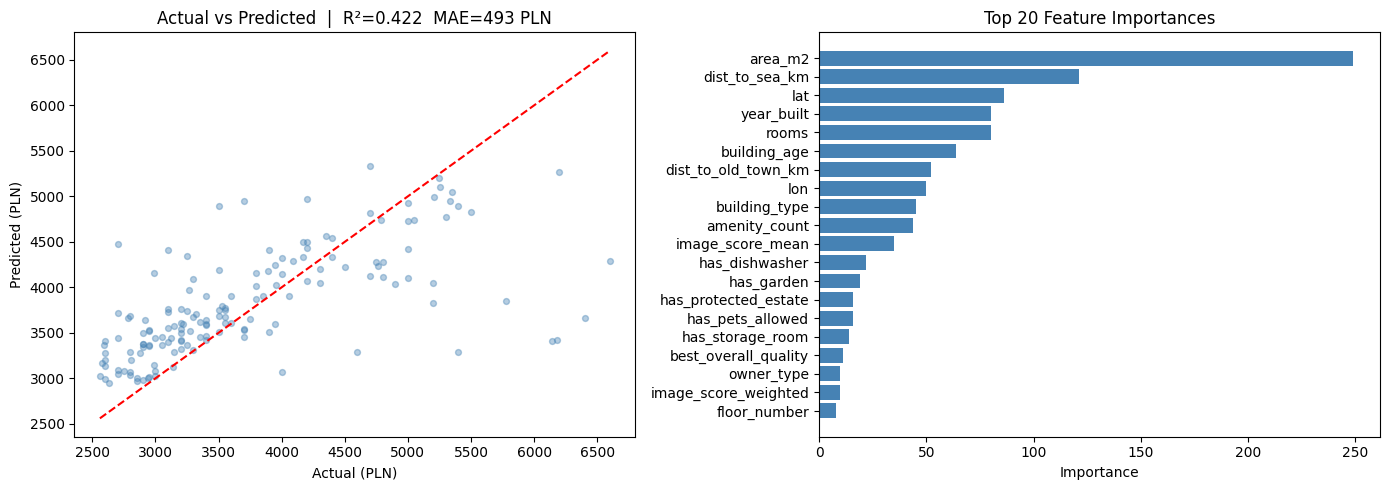

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=18, color='steelblue')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual (PLN)')
axes[0].set_ylabel('Predicted (PLN)')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2:.3f}  MAE={mae:.0f} PLN')

# Feature Importance
fi = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)
axes[1].barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue')
axes[1].set_title('Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150)
plt.show()


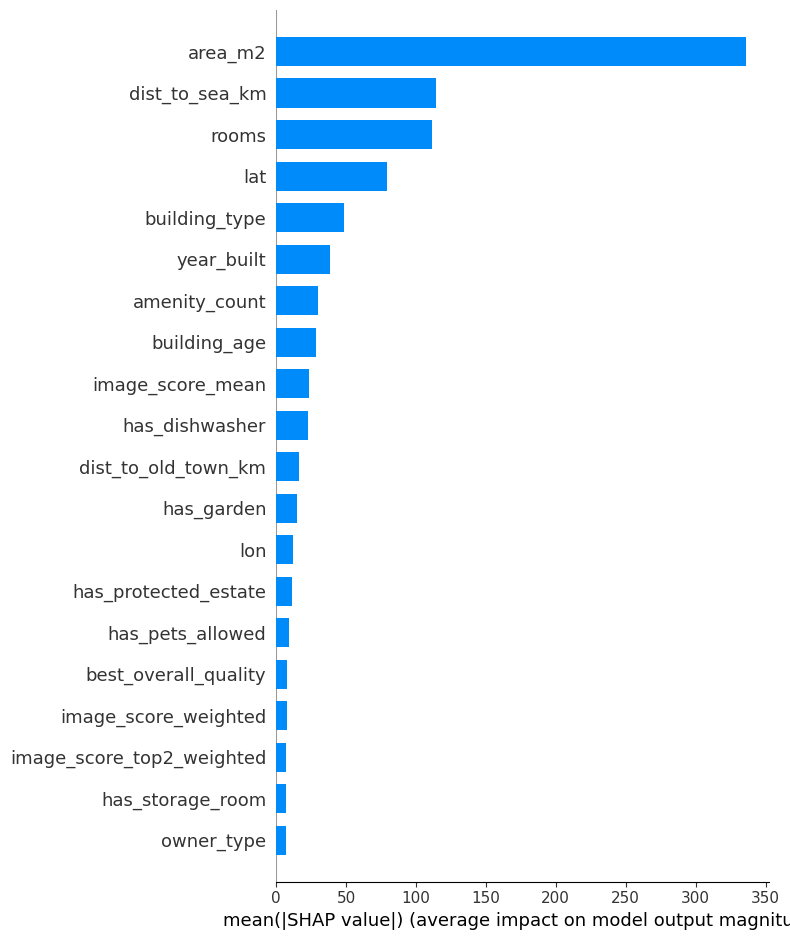

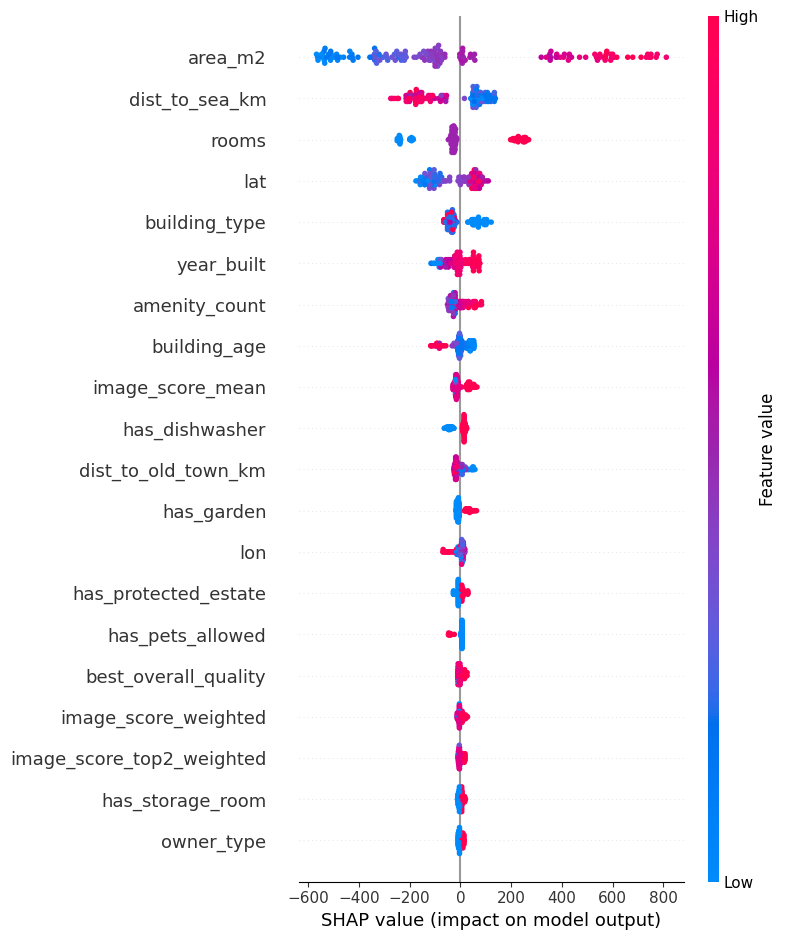

In [ ]:
import shap

explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

# Detailed dot plot (shows direction of effect)
plt.figure()
shap.summary_plot(shap_vals, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_detail.png', dpi=150)
plt.show()